# Bayesian Network Model Evaluation: ROC Curve and Confusion Matrix Analysis

## Overview

This notebook focuses on the evaluation of Bayesian Network (BN) models used for fraud detection. Using discretized transaction data, we obtain model evaluation metrics for the "Semi-Constrained" model that incorporates learned inter-feature relationships. The objective is to analyze how customer personas affects the probability of fraud and to validate the models via posterior predictive checks.

## Pipeline

The notebook has the following workflow:

1. Data Loading: Imports discretized training and testing datasets (Parquet format) and metadata (selected features and learned edges).

2. Model Reconstruction: Builds two discrete Bayesian Networks:

    a. Model A (Naive): Assumes all features point directly to the target variable (fraud_bool) with no inter-dependencies.

    b. Model B (Semi-Constrained): Includes additional edges between features discovered during a prior structure learning phase.

3. Probabilistic Inference: Uses the Variable Elimination algorithm to query the probability of fraud based on specific customer "personas".

4. Model Validation: Conducts a Posterior Predictive Check (PPC) by generating synthetic data from the model and comparing its distribution to real data.

5. Performance Evaluation: Visualizes model performance using ROC curves and Confusion Matrices.

## Methodology

#### 1. Model Architecture:

- Library: The notebook utilizes pgmpy for network structure, parameter estimation (Maximum Likelihood), and inference.

- States: Features are discretized into bins (e.g., income into 3 bins, customer_age into 5 bins). These bins are defined by specific numeric ranges provided in a configuration file.

#### 2. Inference & Personas

- Three distinct scenarios were tested to observe model behavior:

- High-Risk Profile: Features often associated with high risk (e.g., low income, free email).

- Low-Risk Profile: Established customer features (e.g., high income, good credit).

- Partial Observation: Only a subset of features (3 out of 15) is known.

#### 3. Posterior Predictive Checks (PPC)

- To ensure the model accurately captures the underlying data distribution, the model.simulate() method is used to create a synthetic dataset of 800,000 samples. The distributions of real vs. synthetic features are then visualized to check for alignment

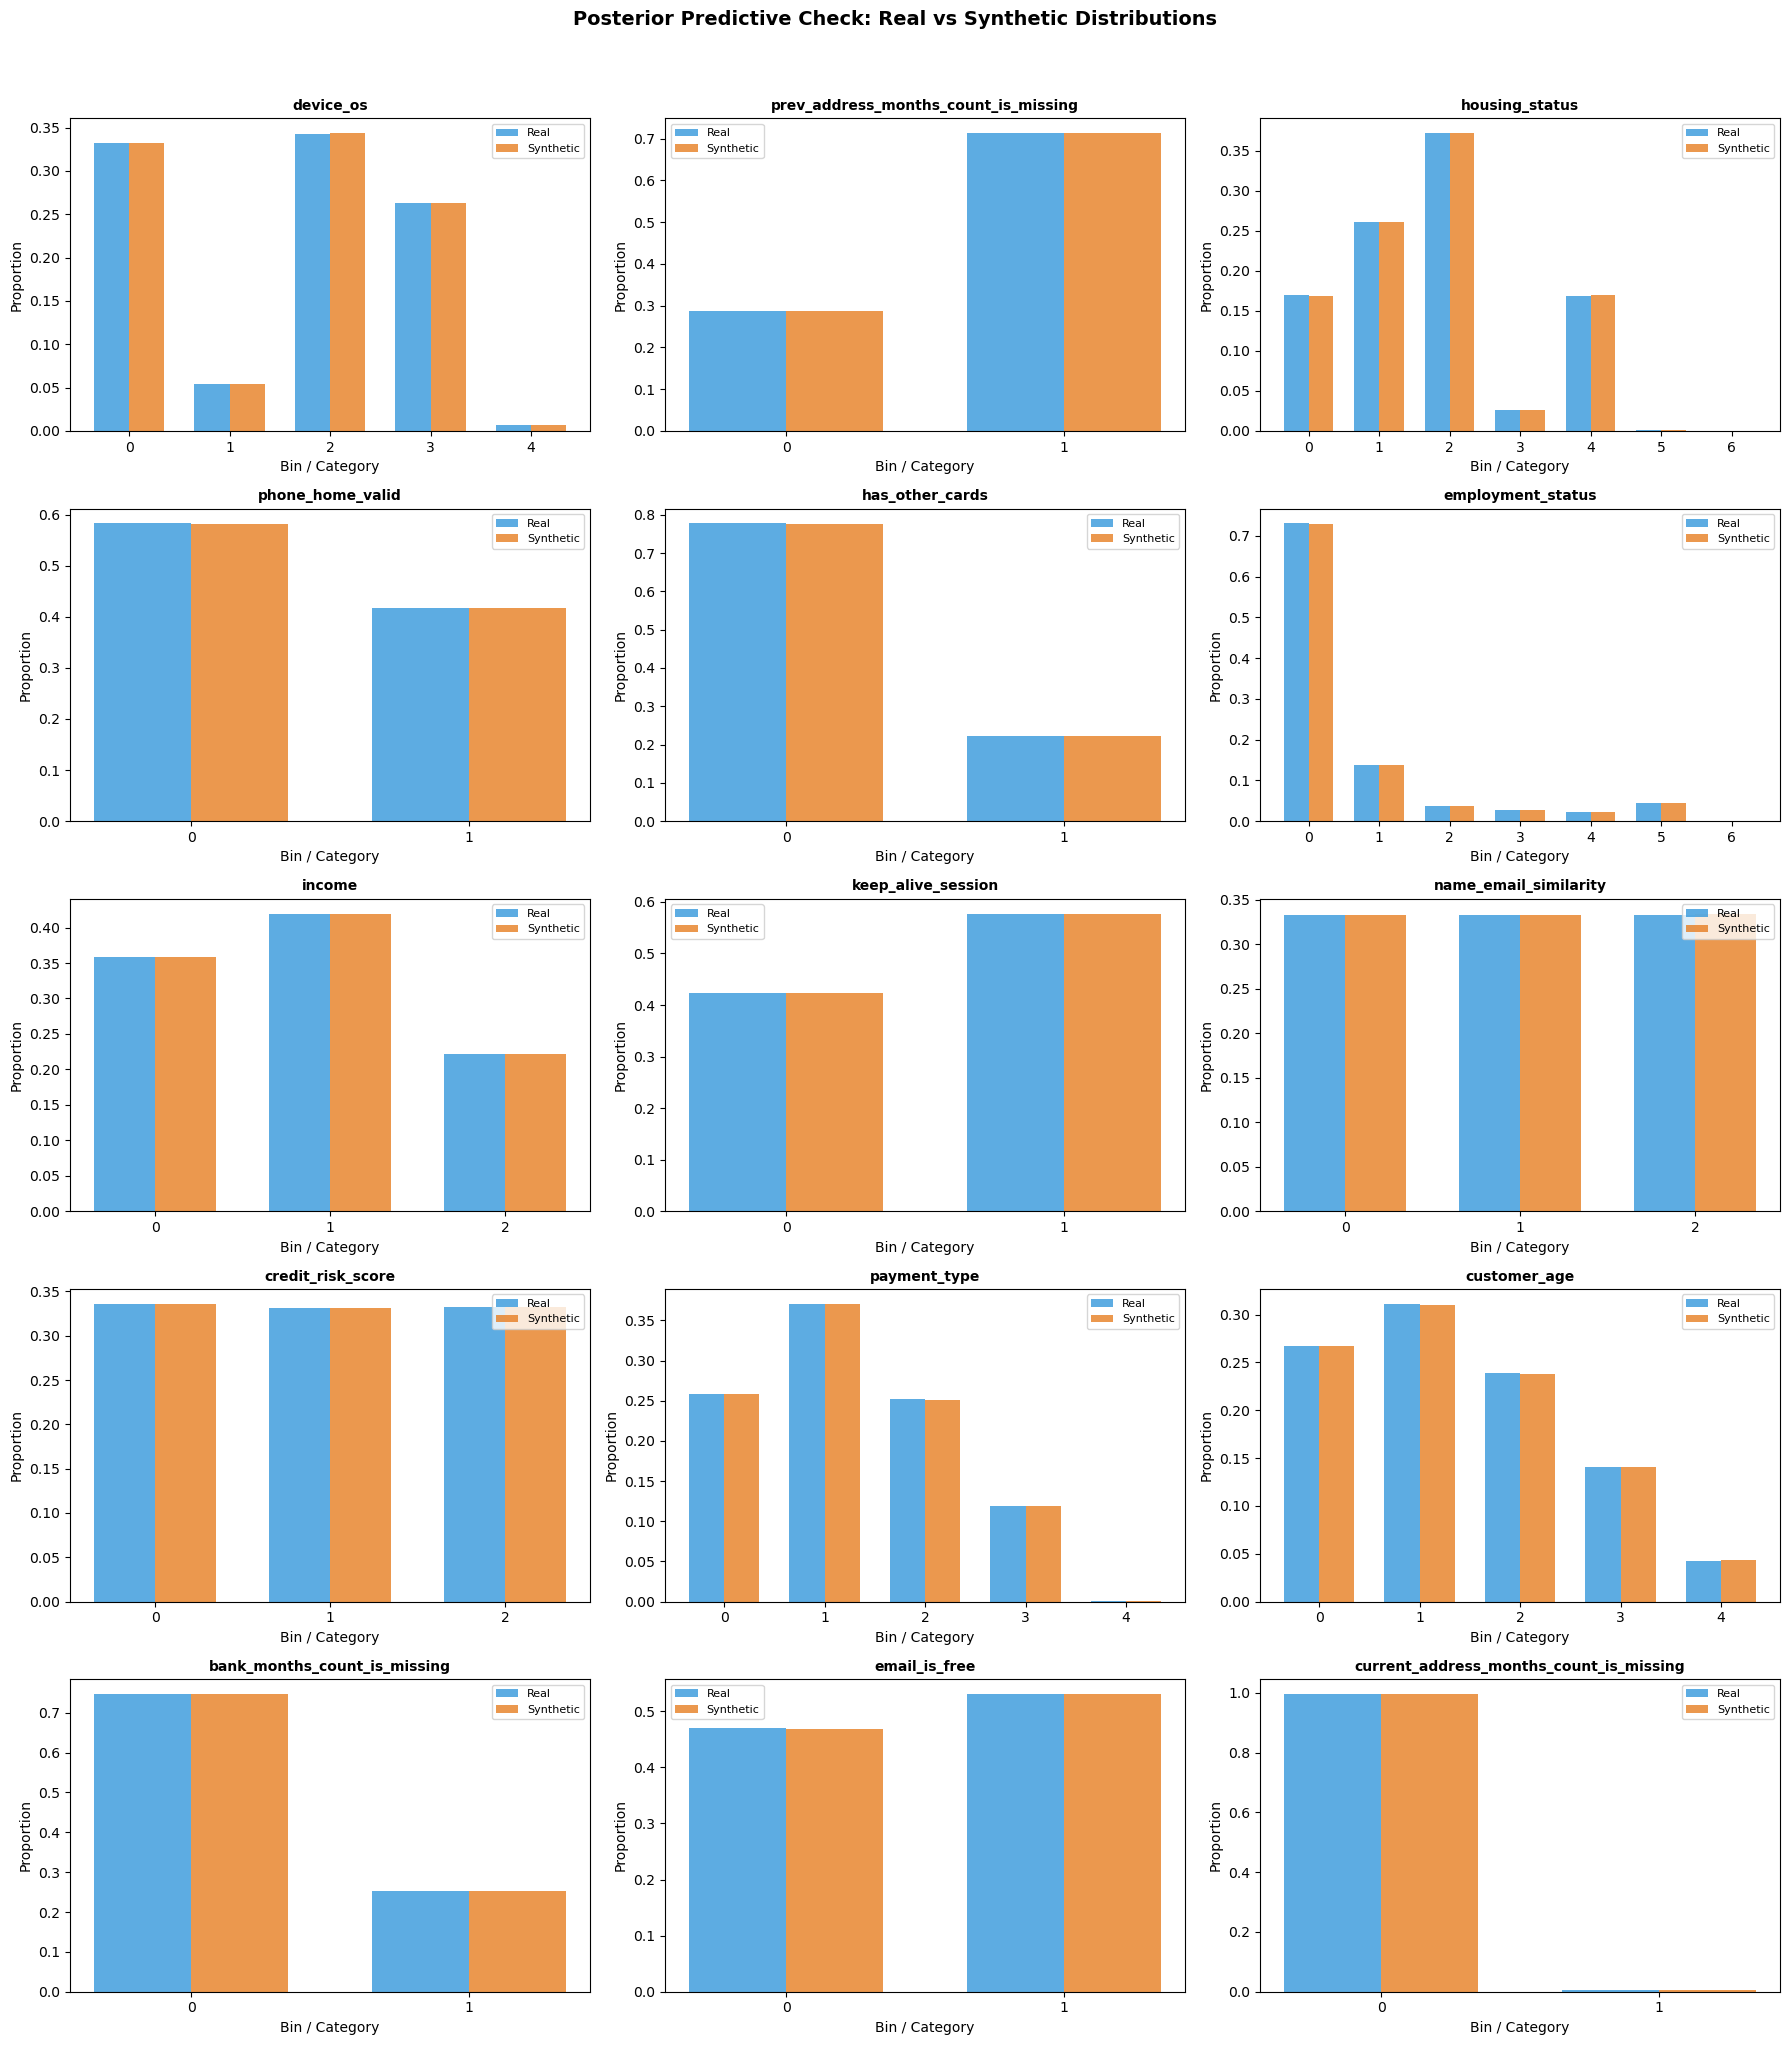

## Findings

#### Probabilistic Divergence
The models revealed significant insights into how feature dependencies influence results:

- For the "High-Risk" persona, the probability of fraud (9.34%) was actually lower than the baseline prior (13.48%). This suggests that in this specific dataset, common "risk" markers are so prevalent among legitimate users that they are not strong discriminators for fraud.

- The "Low-Risk" established customer persona showed a higher probability of fraud (32.64%). This indicates the model learned that fraudsters often create high-credibility profiles to bypass security checks.


#### Value of Model Complexity

- Model B (Semi-Constrained) provided more conservative and realistic estimates under Partial Observation. 

- While Model A (Naive) predicted a 28.78% fraud probability with limited data, Model B predicted 15.66%. Model B's ability to "reason" through inter-feature dependencies makes it more robust when data is missing.

Conclusion: By accounting for feature correlations, Model B prevents the "over-counting" of evidence, leading to more robust behavior in real-world scenarios where data is incomplete.

## Performance Metrics

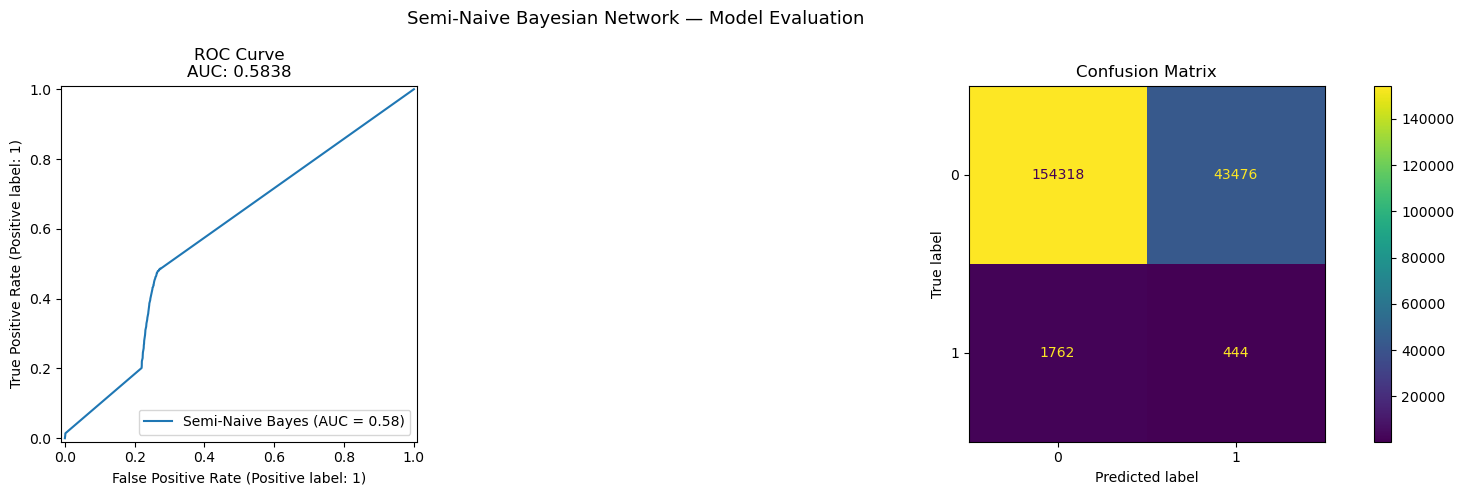

While the inference analysis provides great insight into the relationships between features, the overall predictive power on the test set has room for improvement as shown by the Semi-Naive Bayesian Network AUC of 0.5841

An AUC of 0.58 indicates that while the model is better than random guessing (0.50), it struggles to separate fraud from non-fraud effectively on this specific test data, likely due to the high class imbalance or the discretization losing too much signal.

Comparing the Logistic Regression baseline AUC of 0.88 to the Semi-Naive Bayesian Network AUC (0.58) reveals a significant performance gap. While the Logistic Regression model is highly effective at distinguishing between fraud and non-fraud, the Bayesian Network struggles. 